<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/5FeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

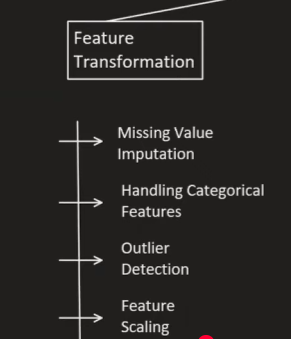

In [5]:
import seaborn as sns
import pandas as pd
import kagglehub
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 4.29MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1


In [7]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1/Social_Network_Ads.csv')

In [12]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
151,15576219,Male,41,45000,0
18,15704583,Male,46,28000,1
395,15691863,Female,46,41000,1
74,15592877,Male,32,18000,0
283,15663249,Female,52,21000,1


In [13]:
df.shape

(400, 5)

In [18]:
df.drop('User ID',axis = 1,inplace = True)
df.drop('Gender',axis = 1,inplace = True)


In [19]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop('Purchased',axis = 1),
                                             df['Purchased'],test_size=0.3,random_state=0)

##Standard Scalling
Xnew = X - MEAN / SD

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(xtrain) #-> this learns the mean and sd of data
xtrain_scaled = scaler.transform(xtrain)
xtestscaled = scaler.transform(xtest)

In [24]:
xtrain_scaled = pd.DataFrame(xtrain_scaled,columns = xtrain.columns)

In [25]:
xtrain_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [32]:
np.round(xtrain.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [31]:
import numpy as np
np.round(xtrain_scaled.describe(),1)   #mean =0 and sd =1

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


##Visualization

/tmp/ipykernel_2577/3309563525.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xtrain['Age'],xtrain['EstimatedSalary'],cmap = 'rainbow')


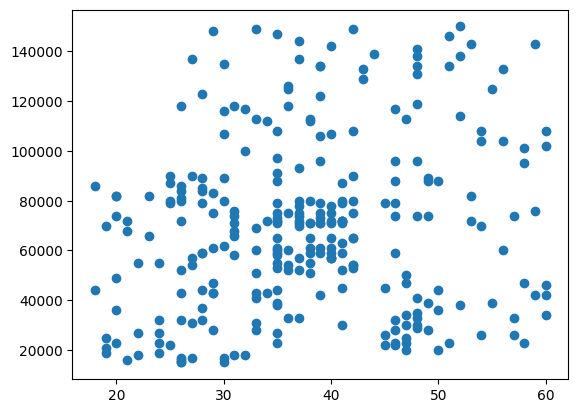

In [49]:
import matplotlib.pyplot as plt
plt.scatter(xtrain['Age'],xtrain['EstimatedSalary'],cmap = 'rainbow')

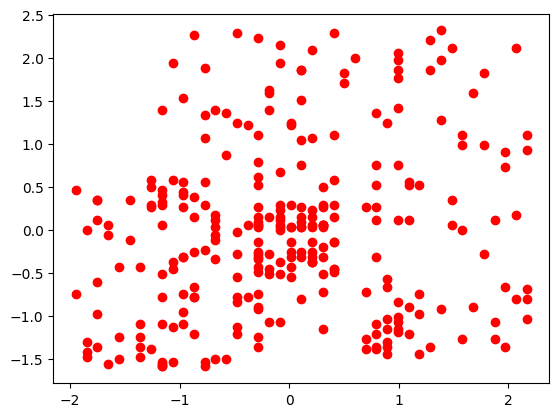

In [53]:
#after scaling
plt.scatter(xtrain_scaled['Age'],xtrain_scaled['EstimatedSalary'],color='red')

In [35]:
age = [20,30,24,56,32,21,45]
df = pd.DataFrame(age,columns = ['age'])

In [42]:
df

,age
0,-1.014110
1,-0.207432
2,-0.691439
3,1.889933
4,-0.046096
5,-0.933442
6,1.002586


In [37]:
df['age'] = scaler.fit_transform(df[['age']])

In [38]:
df

,age
0,-1.014110
1,-0.207432
2,-0.691439
3,1.889933
4,-0.046096
5,-0.933442
6,1.002586


In [41]:
np.round(df.describe(),1)

,age
count,7.0
mean,0.0
std,1.1
min,-1.0
25%,-0.8
50%,-0.2
75%,0.5
max,1.9
